# Processing of a resting-state EEG dataset for sleep deprivation

Bad channels are interpolated

## PRE PROCESSING


#### The intention is to provide epochs(4 seconds) to the machine and try predicting if the case is sleep deprivation or normal sleep.

In [1]:
from matplotlib import pyplot as plt
import os
import pandas as pd
import numpy as np
from scipy import signal
import mne
import mne_icalabel
from mne.preprocessing import ICA
from autoreject import Ransac  
from mne_icalabel import label_components
%matplotlib inline

In [2]:
# lists to collect data
X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []

In [3]:
n_epochs = 0
for i in range(1, 72):
    if i == 28 or i== 1 or i== 44 or i==39 or i==43 or i in [7,8,11,13,18,24,29,31,35,36,37,38,40,47,48,50,54,58,59,63,67,70,71]:
        continue  # Skip participant 1,28 due to missing data
    for j in range(1, 3):
        
        #Define file path
        file_path = f'D:\\BCI\\TASKS\\Task-8\\ds004902_data\\sub-{i:02d}\\ses-{j}\\eeg\\sub-{i:02d}_ses-{j}_task-eyesopen_eeg.set'#The d indicates that the value is a decimal integer, while the 02 specifies that the output should be padded with leading zeros if necessary to reach a width of two characters.
        epochs_file = f'D:\\BCI\\TASKS\\Task-8\\processed_epochs_60\\sub-{i:02d}_ses-{j}_epochs.fif'  # Path to save/load processed epochs
        
        
        if os.path.exists(epochs_file):
            print(f"Loading processed epochs from {epochs_file}")
            epochs = mne.read_epochs(epochs_file, preload=True)
        else:
            print(f"\nProcessing: {file_path}\n")

            #Define EEG channels
            eeg_channels = ["Fp1", "AF3", "AF7", "Fz", "F1", "F3", "F5", "F7","FC1", "FC3", "FC5", "FT7","Cz", "C1", "C3", "C5", "T7","CP1", "CP3", "CP5", "TP7", "TP9","Pz", "P1", "P3", "P5", "P7","PO3", "PO7", "Oz", "O1","Fpz", "Fp2", "AF4", "AF8","F2", "F4", "F6", "F8","FC2", "FC4", "FC6", "FT8","C2", "C4", "C6", "T8","CPz", "CP2", "CP4", "CP6","TP8", "TP10","P2", "P4", "P6", "P8","POz", "PO4", "PO8", "O2"]
            
            #Load EEG data
            raw = mne.io.read_raw_eeglab(file_path, preload=True)
            eeg_raw=raw.pick(mne.pick_channels(raw.info['ch_names'], include=eeg_channels))
            
            #Montage setting
            montage = mne.channels.make_standard_montage('standard_1020')
            eeg_raw.set_montage(montage)

            #Filtering
            eeg_raw.filter(1., 40.)#, fir_design='firwin')

            #Average Referencing
            eeg_raw.set_eeg_reference('average', projection=False)

            #EPOCHING
            epochs = mne.make_fixed_length_epochs(eeg_raw, duration=60.0, overlap=0.0,preload=True)

            #RANSAC for bad channel detection
            ransac = Ransac(verbose=False, n_jobs=1)
            ransac.fit(epochs)
            epochs.info['bads'].extend(ransac.bad_chs_)   

            #interpolate bad channels
            epochs.interpolate_bads(reset_bads=True)
            
            #ICA for artifact removal
            ica = mne.preprocessing.ICA(n_components=20, method='infomax', fit_params=dict(extended=True), random_state=42, max_iter=1000)
            ica.fit(epochs)

            ic_labels = label_components(epochs, ica, method='iclabel')
            exclude_idx = []
            for idx, label in enumerate(ic_labels["labels"]):
                if label not in ["brain","other","muscle artifact"] and ic_labels["y_pred_proba"][idx] > 0.5:
                    exclude_idx.append(idx)

            ica.apply(epochs,exclude= exclude_idx)        

            # Save processed epochs
            os.makedirs(os.path.dirname(epochs_file), exist_ok=True) #creates the necessary directories for the file path if they don't exist.
            epochs.save(epochs_file, overwrite=True)
            print(f"Saved processed epochs to {epochs_file}")

        if j==1:
            labels = 0
        elif j==2:
            labels = 1
        labels = pd.DataFrame({'label': [labels]*len(epochs)})
        
        # Extract data and labels
        data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)

        if (i == 39 or i == 43) and j == 2:
            data = signal.decimate(data, 10, axis=2) # Downsample by a factor of 10 to match time points.

        epoch_labels = labels['label'].values  
        
        if i <= 56:  # Training data
            X_train_list.append(data)
            y_train_list.append(epoch_labels)
        else:  # Testing data
            X_test_list.append(data)
            y_test_list.append(epoch_labels)

# After the loop, concatenate into arrays
X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)
X_test = np.concatenate(X_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)
print("Training and testing data processing complete")

Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-2_epochs.fif ...


C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\3201286983.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\3201286983.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-03_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-03_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-03_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-03_ses-2_epochs.fif ...
    Found the data of interest:


C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\3201286983.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-03_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\3201286983.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-03_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-04_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-04_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-04_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-04_ses-2_epochs.fif ...


...

    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-68_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-68_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-68_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-68_ses-2_epochs.fif ...


C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\3201286983.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-68_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\3201286983.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-68_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-2_epochs.fif ...
    Found the data of interest:


C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\3201286983.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)
C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\3201286983.py:14: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Training and testing data processing complete


In [4]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((339, 61, 30000), (339,), (85, 61, 30000), (85,))

In [5]:
X_train

array([[[-1.86939514e-09, -1.33587992e-06, -2.67785286e-06, ...,
          3.39845633e-06,  2.90296911e-06,  2.38385891e-06],
        [-1.94064725e-09,  1.98257356e-07,  1.31205871e-07, ...,
          6.59083508e-06,  6.43760393e-06,  6.10524176e-06],
        [-1.08360790e-09, -6.29877148e-07, -1.39925456e-06, ...,
          2.80599474e-06,  2.63128828e-06,  2.36371660e-06],
        ...,
        [ 4.23254502e-10,  1.06595909e-06,  2.29082608e-06, ...,
          1.41882562e-06,  2.76843046e-06,  3.73536276e-06],
        [ 4.71726466e-10,  2.87471890e-07,  8.53711305e-07, ...,
          1.00523967e-05,  1.02179270e-05,  9.79988763e-06],
        [ 5.23308931e-10,  1.85923862e-06,  3.72308849e-06, ...,
          3.99468016e-06,  6.16059874e-06,  7.70940350e-06]],

       [[ 1.86271786e-06,  1.33896160e-06,  7.96520708e-07, ...,
         -9.06401095e-07, -8.24688671e-08,  6.52927635e-07],
        [ 5.61213015e-06,  4.99401473e-06,  4.29776095e-06, ...,
         -4.90488957e-06, -4.45498608e

## FEATURE EXTRACTION 

In [6]:
from scipy import stats

In [7]:
#Time-domain feature extraction functions
def mean(sample_data):
    return np.mean(sample_data, axis=-1)

def std(sample_data):
    return np.std(sample_data, axis=-1)

def zscore(sample_data):
    return stats.zscore(sample_data, axis=-1)

def ptp(sample_data):
    return np.ptp(sample_data, axis=-1)

def min(sample_data):
    return np.min(sample_data, axis=-1)

def max(sample_data):
    return np.max(sample_data, axis=-1)

def var(sample_data):
    return np.var(sample_data, axis=-1)

def rms(sample_data):
    return np.sqrt(np.mean(sample_data**2, axis=-1))

def skewness(sample_data):
    return stats.skew(sample_data, axis=-1)   

def kurtosis(sample_data):
    return stats.kurtosis(sample_data, axis=-1)


def mean_square(sample_data):
    return np.mean(sample_data**2, axis=-1)

def hjorth_params(sample_data):
    first_deriv = np.diff(sample_data, axis=-1)
    second_deriv = np.diff(first_deriv, axis=-1)

    var_zero = var(sample_data)
    var_d1 = var(first_deriv)
    var_d2 = var(second_deriv)
    
    activity = var_zero
    mobility = np.sqrt(var_d1 / var_zero)
    complexity = np.sqrt(var_d2 / var_d1) / mobility
    
    return activity, mobility, complexity

In [8]:
# Frequency-domain feature extraction functions
def bandpower_delta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    delta_band = (0.5, 4)
    mask = (freqs >= delta_band[0]) & (freqs <= delta_band[1])
    delta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return delta_power

def bandpower_theta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    theta_band = (4, 8)
    mask = (freqs >= theta_band[0]) & (freqs <= theta_band[1])
    theta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return theta_power

def bandpower_alpha(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    alpha_band = (8, 13)
    mask = (freqs >= alpha_band[0]) & (freqs <= alpha_band[1])
    alpha_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return alpha_power  

def bandpower_beta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    beta_band = (13, 30)
    mask = (freqs >= beta_band[0]) & (freqs <= beta_band[1])
    beta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return beta_power       

def bandpower_gamma(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    gamma_band = (30, 40)
    mask = (freqs >= gamma_band[0]) & (freqs <= gamma_band[1])
    gamma_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return gamma_power

def spectral_entropy(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    psd_norm = psd_values / np.sum(psd_values, axis=axis, keepdims=True)
    spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-10), axis=axis)
    return spectral_entropy

In [9]:
def feature_concatination(sample_data):
    feature_vector = []
    
    '''# Time-domain features
    feature_vector.append(mean(sample_data))
    feature_vector.append(std(sample_data))
    feature_vector.append(ptp(sample_data))
    #feature_vector.append(min(sample_data))
    #feature_vector.append(max(sample_data))
    #feature_vector.append(var(sample_data))
    #feature_vector.append(rms(sample_data))
    feature_vector.append(skewness(sample_data))
    feature_vector.append(kurtosis(sample_data))
    activity, mobility, complexity = hjorth_params(sample_data)
    feature_vector.append(activity)
    feature_vector.append(mobility)
    feature_vector.append(complexity)'''
    
    # Frequency-domain features
    feature_vector.append(bandpower_delta(sample_data))
    feature_vector.append(bandpower_theta(sample_data))
    feature_vector.append(bandpower_alpha(sample_data))
    feature_vector.append(bandpower_beta(sample_data))
    feature_vector.append(bandpower_gamma(sample_data))
    feature_vector.append(spectral_entropy(sample_data))
    
    return np.concatenate(feature_vector, axis=-1)

In [10]:
from tqdm import tqdm_notebook
X_train_features=[]
for datta in tqdm_notebook(X_train):
    features = feature_concatination(datta)
    X_train_features.append(features)

X_train_features=np.array(X_train_features)
X_train_features.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\1365453675.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(X_train):


  0%|          | 0/339 [00:00<?, ?it/s]

(339, 366)

In [11]:
from tqdm import tqdm_notebook
X_test_features=[]
for datta in tqdm_notebook(X_test):
    features = feature_concatination(datta)
    X_test_features.append(features)

X_test_features=np.array(X_test_features)
X_test_features.shape  #(2191 , 1098) --> 61 channels x 18 features per channel

C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\2217720568.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(X_test):


  0%|          | 0/85 [00:00<?, ?it/s]

(85, 366)

## MACHINE LEARNING

In [12]:
from sklearn.ensemble import RandomForestClassifier

In [13]:
# Instantiate model with 1000 decision trees
rf = RandomForestClassifier(n_estimators = 1000, random_state = 42)
# Train the model on training data
rf.fit(X_train_features, y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [14]:
predictions = rf.predict(X_test_features)

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[24 20]
 [11 30]]


Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.55      0.61        44
           1       0.60      0.73      0.66        41

    accuracy                           0.64        85
   macro avg       0.64      0.64      0.63        85
weighted avg       0.64      0.64      0.63        85



Accuracy: 0.6352941176470588


In [16]:
from sklearn.svm import SVC

In [17]:
model = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42) #default parameters
model.fit(X_train_features, y_train)

SVC(random_state=42)

In [18]:
predictions = model.predict(X_test_features)

In [19]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[44  0]
 [41  0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.52      1.00      0.68        44
           1       0.00      0.00      0.00        41

    accuracy                           0.52        85
   macro avg       0.26      0.50      0.34        85
weighted avg       0.27      0.52      0.35        85



Accuracy: 0.5176470588235295


c:\Users\suvan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\suvan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\suvan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [20]:
#Grid Search CV for SVM hyperparameter tuning
from sklearn.model_selection import GridSearchCV

In [21]:
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'gamma': ['scale', 'auto']}

In [22]:
#grid= GridSearchCV(model, param_grid, refit=True, verbose=3)
#grid.fit(X_train_features, y_train)

In [23]:
#grid.best_params_

In [24]:
#grid.best_estimator_

In [25]:
#grid_predictions = grid.predict(X_test_features)

In [26]:
'''cm = confusion_matrix(y_test, grid_predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, grid_predictions)
print("Classification Report:\n", cf)   
print("\n")
accuracy = accuracy_score(y_test, grid_predictions)
print("Accuracy:", accuracy)'''

'cm = confusion_matrix(y_test, grid_predictions)\nprint("Confusion Matrix:\n", cm)\nprint("\n")\ncf = classification_report(y_test, grid_predictions)\nprint("Classification Report:\n", cf)   \nprint("\n")\naccuracy = accuracy_score(y_test, grid_predictions)\nprint("Accuracy:", accuracy)'

In [27]:
from xgboost import XGBClassifier

In [28]:
XGB = XGBClassifier(n_estimators=1000,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,objective='multi:softmax',num_class=2,eval_metric='mlogloss',tree_method='auto')

In [29]:
XGB.fit(X_train_features, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None, num_class=2, ...)

In [30]:
predictions = XGB.predict(X_test_features)

In [31]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[24 20]
 [13 28]]


Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.55      0.59        44
           1       0.58      0.68      0.63        41

    accuracy                           0.61        85
   macro avg       0.62      0.61      0.61        85
weighted avg       0.62      0.61      0.61        85



Accuracy: 0.611764705882353


In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [33]:
knn = KNeighborsClassifier(n_neighbors=5)

In [34]:
knn.fit(X_train_features, y_train)

KNeighborsClassifier()

In [35]:
predictions = knn.predict(X_test_features)

In [36]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[29 15]
 [24 17]]


Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.66      0.60        44
           1       0.53      0.41      0.47        41

    accuracy                           0.54        85
   macro avg       0.54      0.54      0.53        85
weighted avg       0.54      0.54      0.53        85



Accuracy: 0.5411764705882353


In [37]:
error_rate = []

for i in range(1,100):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_features,y_train)
    pred_i = knn.predict(X_test_features)
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

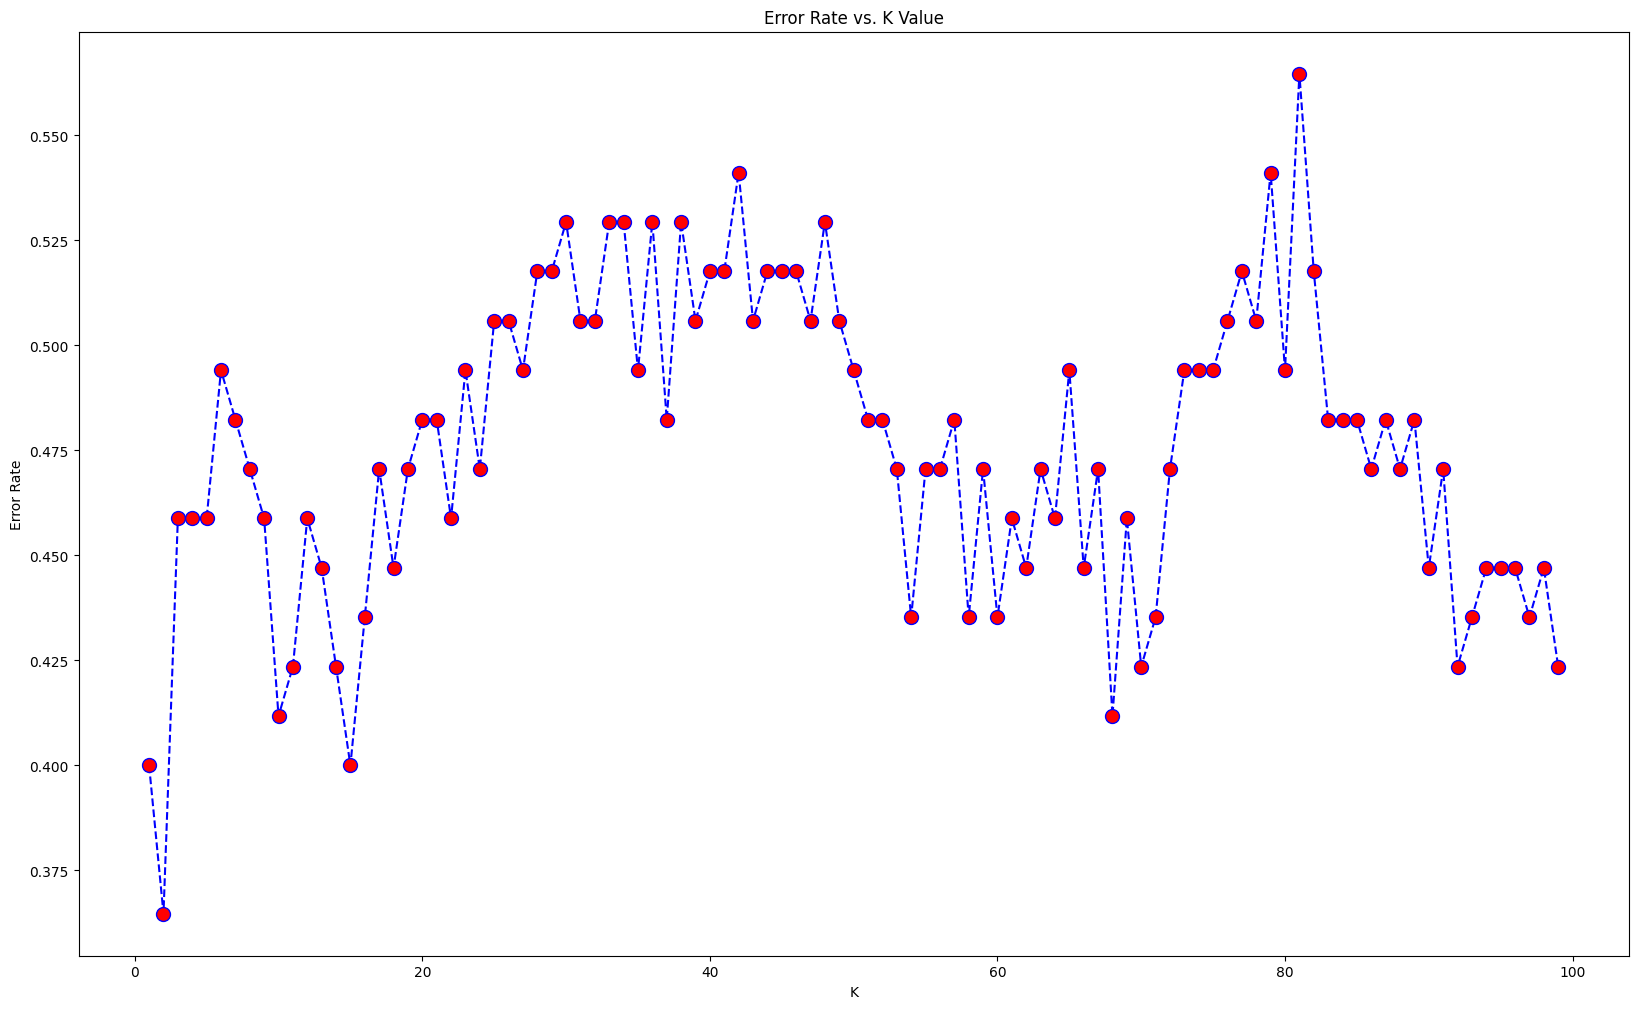

In [38]:
plt.figure(figsize=(20,12))
plt.plot(range(1,100),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [39]:
knn_new = KNeighborsClassifier(n_neighbors=1)

In [40]:
knn_new.fit(X_train_features, y_train)

KNeighborsClassifier(n_neighbors=1)

In [41]:
predictions = knn_new.predict(X_test_features)

In [42]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[33 11]
 [23 18]]


Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.75      0.66        44
           1       0.62      0.44      0.51        41

    accuracy                           0.60        85
   macro avg       0.60      0.59      0.59        85
weighted avg       0.60      0.60      0.59        85



Accuracy: 0.6


### Best Accuracy: 81

### Leave One Out Cross Validation

In [43]:
from sklearn.model_selection import LeaveOneOut

In [44]:
X_all = np.vstack((X_train_features, X_test_features))
y_all = np.concatenate((y_train, y_test))

print(f"Total shape of features: {X_all.shape}")
print(f"Total shape of labels: {y_all.shape}")

Total shape of features: (424, 366)
Total shape of labels: (424,)


In [ ]:
y_true = []
y_pred = []
Accuracy_rf = []
loo = LeaveOneOut()
for train_index, test_index in tqdm_notebook(loo.split(X_all), total=len(X_all)):
    X_train_cv, X_test_cv = X_all[train_index], X_all[test_index]
    y_train_cv, y_test_cv = y_all[train_index], y_all[test_index]
    
    rf.fit(X_train_cv, y_train_cv)
    prediction = rf.predict(X_test_cv)
    y_true.append(y_test_cv[0])
    y_pred.append(prediction[0])
    Accuracy = Accuracy_rf.append(accuracy_score(y_true, y_pred))
    print("\nAccuracy:", accuracy_score(y_true, y_pred))

In [ ]:
y_true = []
y_pred = []
Accuracy_XGB = []
loo = LeaveOneOut()
for train_index, test_index in tqdm_notebook(loo.split(X_all), total=len(X_all)):
    X_train_cv, X_test_cv = X_all[train_index], X_all[test_index]
    y_train_cv, y_test_cv = y_all[train_index], y_all[test_index]
    
    XGB.fit(X_train_cv, y_train_cv)
    prediction = XGB.predict(X_test_cv)
    y_true.append(y_test_cv[0])
    y_pred.append(prediction[0])
    Accuracy = Accuracy_XGB.append(accuracy_score(y_true, y_pred))
    print("\nAccuracy:", accuracy_score(y_true, y_pred))

C:\Users\suvan\AppData\Local\Temp\ipykernel_17312\1165820530.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for train_index, test_index in tqdm_notebook(loo.split(X_all), total=len(X_all)):


  0%|          | 0/424 [00:00<?, ?it/s]


Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 1.0

Accuracy: 0.9615384615384616

Accuracy: 0.9629629629629629

Accuracy: 0.9642857142857143

Accuracy: 0.9655172413793104

Accuracy: 0.9666666666666667

Accuracy: 0.967741935483871

Accuracy: 0.96875

Accuracy: 0.9696969696969697

Accuracy: 0.9705882352941176

Accuracy: 0.9714285714285714

Accuracy: 0.9722222222222222

Accuracy: 0.972972972972973

Accuracy: 0.9736842105263158

Accuracy: 0.9743589743589743

Accuracy: 0.975

Accuracy: 0.975609756097561

Accuracy: 0.9761904761904762

Accuracy: 0.9767441860465116

Accuracy: 0.9772727272727273

Accuracy: 0.9777777777777777

Accuracy: 0.9782608695652174

Accuracy: 0.978723404

In [46]:
groups_list = []
for i in range(1, 72):
    if i in [1,7,8,11,13,18,24,28,29,31,35,36,37,38,39,40,43,44,47,48,50,54,58,59,63,67,70,71]: 
        continue
    for j in range(1, 3):
        epochs_file = f'D:\\BCI\\TASKS\\Task-8\\processed_epochs_60\\sub-{i:02d}_ses-{j}_epochs.fif'
        if os.path.exists(epochs_file):
            # preload=False makes this instantly read just the shape/metadata
            epochs = mne.read_epochs(epochs_file, preload=False, verbose=False)
            groups_list.extend([i] * len(epochs))

groups = np.array(groups_list)
print(f"Total features shape: {X_all.shape}")
print(f"Total labels shape: {y_all.shape}")
print(f"Total groups shape: {groups.shape}")

C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\979239417.py:9: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=False, verbose=False)
C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\979239417.py:9: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=False, verbose=False)
C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\979239417.py:9: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-03_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  

Total features shape: (424, 366)
Total labels shape: (424,)
Total groups shape: (424,)


C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\979239417.py:9: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-66_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=False, verbose=False)
C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\979239417.py:9: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-68_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=False, verbose=False)
C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\979239417.py:9: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-68_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  

In [47]:
from sklearn.model_selection import LeaveOneGroupOut
logo = LeaveOneGroupOut()

In [48]:
y_true_all = []
y_pred_all = []
Accuracy_rf_1 = []
n_splits = logo.get_n_splits(X_all, y_all, groups=groups)
for train_index, test_index in tqdm_notebook(logo.split(X_all, y_all, groups=groups), total=n_splits):
    X_train_cv, X_test_cv = X_all[train_index], X_all[test_index]
    y_train_cv, y_test_cv = y_all[train_index], y_all[test_index]

    rf.fit(X_train_cv, y_train_cv)
    predictions = model.predict(X_test_cv)
    y_true_all.extend(y_test_cv)
    y_pred_all.extend(predictions)

    y_true_all.append(y_test_cv[0])
    y_pred_all.append(prediction[0])
    Accuracy = Accuracy_rf_1.append(accuracy_score(y_true_all, y_pred_all))
    print("\nAccuracy:", accuracy_score(y_true_all, y_pred_all))

C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\1313436946.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for train_index, test_index in tqdm_notebook(logo.split(X_all, y_all, groups=groups), total=n_splits):


  0%|          | 0/43 [00:00<?, ?it/s]


Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.45454545454545453

Accuracy: 0.4560260586319218

Accuracy: 0.4559748427672956

Accuracy: 0.4573170731707317

Accuracy: 0.45588235294117646

Accuracy: 0.45584045584045585

Accuracy: 

In [49]:
y_true_all = []
y_pred_all = []
Accuracy_XGB_1 = []
n_splits = logo.get_n_splits(X_all, y_all, groups=groups)
for train_index, test_index in tqdm_notebook(logo.split(X_all, y_all, groups=groups), total=n_splits):
    X_train_cv, X_test_cv = X_all[train_index], X_all[test_index]
    y_train_cv, y_test_cv = y_all[train_index], y_all[test_index]

    XGB.fit(X_train_cv, y_train_cv)
    predictions = XGB.predict(X_test_cv)
    y_true_all.extend(y_test_cv)
    y_pred_all.extend(predictions)

    y_true_all.append(y_test_cv[0])
    y_pred_all.append(prediction[0])
    Accuracy = Accuracy_XGB_1.append(accuracy_score(y_true_all, y_pred_all))
    print("\nAccuracy:", accuracy_score(y_true_all, y_pred_all))

C:\Users\suvan\AppData\Local\Temp\ipykernel_26632\748275362.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for train_index, test_index in tqdm_notebook(logo.split(X_all, y_all, groups=groups), total=n_splits):


  0%|          | 0/43 [00:00<?, ?it/s]


Accuracy: 0.45454545454545453

Accuracy: 0.5454545454545454

Accuracy: 0.5151515151515151

Accuracy: 0.5

Accuracy: 0.509090909090909

Accuracy: 0.5

Accuracy: 0.4935064935064935

Accuracy: 0.48863636363636365

Accuracy: 0.5252525252525253

Accuracy: 0.5181818181818182

Accuracy: 0.5041322314049587

Accuracy: 0.5

Accuracy: 0.4965034965034965

Accuracy: 0.5

Accuracy: 0.5272727272727272

Accuracy: 0.5227272727272727

Accuracy: 0.5187165775401069

Accuracy: 0.5151515151515151

Accuracy: 0.5119617224880383

Accuracy: 0.5181818181818182

Accuracy: 0.5324675324675324

Accuracy: 0.5495867768595041

Accuracy: 0.549407114624506

Accuracy: 0.5492424242424242

Accuracy: 0.5490909090909091

Accuracy: 0.541958041958042

Accuracy: 0.5353535353535354

Accuracy: 0.5244299674267101

Accuracy: 0.5345911949685535

Accuracy: 0.5304878048780488

Accuracy: 0.5352941176470588

Accuracy: 0.5356125356125356

Accuracy: 0.5414364640883977

Accuracy: 0.5495978552278821

Accuracy: 0.5509138381201044

Accuracy: 